In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv(r"C:\Users\spnra\OneDrive\Documents\customer_churn_ann_dataset.csv")
df.head()

,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,1001,Male,0,1,29.85,29.85,Month-to-month,DSL,Electronic check,Yes
1,1002,Female,0,34,56.95,1889.50,One year,Fiber optic,Mailed check,No
2,1003,Female,0,2,53.85,108.70,Month-to-month,DSL,Electronic check,Yes
3,1004,Male,1,45,70.70,3190.50,Two year,Fiber optic,Bank transfer,No
4,1005,Male,0,12,99.65,1194.00,Month-to-month,Fiber optic,Electronic check,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       15 non-null     int64  
 1   Gender           15 non-null     object 
 2   SeniorCitizen    15 non-null     int64  
 3   Tenure           15 non-null     int64  
 4   MonthlyCharges   15 non-null     float64
 5   TotalCharges     15 non-null     float64
 6   Contract         15 non-null     object 
 7   InternetService  15 non-null     object 
 8   PaymentMethod    15 non-null     object 
 9   Churn            15 non-null     object 
dtypes: float64(2), int64(3), object(5)
memory usage: 1.3+ KB


In [8]:
print("Rows:",df.shape[0])
print("Column:",df.shape[1])

Rows: 15
Column: 10


In [9]:
df.isnull().sum()

CustomerID         0
Gender             0
SeniorCitizen      0
Tenure             0
MonthlyCharges     0
TotalCharges       0
Contract           0
InternetService    0
PaymentMethod      0
Churn              0
dtype: int64

In [10]:
df.describe()

,CustomerID,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,1008.000000,0.266667,25.133333,70.343333,2002.033333
std,4.472136,0.457738,23.117299,22.457832,2204.170556
min,1001.000000,0.000000,1.000000,29.850000,29.850000
25%,1004.500000,0.000000,6.000000,55.400000,321.225000
50%,1008.000000,0.000000,18.000000,70.700000,1194.000000
75%,1011.500000,0.500000,40.500000,88.850000,2893.950000
max,1015.000000,1.000000,72.000000,105.500000,7596.000000


In [11]:
df["Churn"].value_counts()

Churn
No     8
Yes    7
Name: count, dtype: int64

In [12]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [13]:
df = df.drop_duplicates()

In [14]:
df.isnull().sum()

CustomerID         0
Gender             0
SeniorCitizen      0
Tenure             0
MonthlyCharges     0
TotalCharges       0
Contract           0
InternetService    0
PaymentMethod      0
Churn              0
dtype: int64

In [15]:
df = df.dropna()

In [16]:
df = df.drop("CustomerID",axis=1)
df.head()

,Gender,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,Male,0,1,29.85,29.85,Month-to-month,DSL,Electronic check,Yes
1,Female,0,34,56.95,1889.50,One year,Fiber optic,Mailed check,No
2,Female,0,2,53.85,108.70,Month-to-month,DSL,Electronic check,Yes
3,Male,1,45,70.70,3190.50,Two year,Fiber optic,Bank transfer,No
4,Male,0,12,99.65,1194.00,Month-to-month,Fiber optic,Electronic check,Yes


In [17]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})
df.head()

,Gender,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,0,0,1,29.85,29.85,Month-to-month,DSL,Electronic check,Yes
1,1,0,34,56.95,1889.50,One year,Fiber optic,Mailed check,No
2,1,0,2,53.85,108.70,Month-to-month,DSL,Electronic check,Yes
3,0,1,45,70.70,3190.50,Two year,Fiber optic,Bank transfer,No
4,0,0,12,99.65,1194.00,Month-to-month,Fiber optic,Electronic check,Yes


In [18]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})
df.head()

,Gender,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,0,0,1,29.85,29.85,Month-to-month,DSL,Electronic check,1
1,1,0,34,56.95,1889.50,One year,Fiber optic,Mailed check,0
2,1,0,2,53.85,108.70,Month-to-month,DSL,Electronic check,1
3,0,1,45,70.70,3190.50,Two year,Fiber optic,Bank transfer,0
4,0,0,12,99.65,1194.00,Month-to-month,Fiber optic,Electronic check,1


In [19]:
df = pd.get_dummies(
    df,
    columns=["Contract", "InternetService", "PaymentMethod"],
    drop_first=True
)
df.head()

,Gender,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,1,False,False,False,False,False,True,False
1,1,0,34,56.95,1889.50,0,True,False,True,False,False,False,True
2,1,0,2,53.85,108.70,1,False,False,False,False,False,True,False
3,0,1,45,70.70,3190.50,0,False,True,True,False,False,False,False
4,0,0,12,99.65,1194.00,1,False,False,True,False,False,True,False


In [20]:
x = df.drop("Churn",axis=1)
df.head()

,Gender,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,1,False,False,False,False,False,True,False
1,1,0,34,56.95,1889.50,0,True,False,True,False,False,False,True
2,1,0,2,53.85,108.70,1,False,False,False,False,False,True,False
3,0,1,45,70.70,3190.50,0,False,True,True,False,False,False,False
4,0,0,12,99.65,1194.00,1,False,False,True,False,False,True,False


In [21]:
y = df["Churn"]
print(x.shape)
print(y.shape)

(15, 12)
(15,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12, 12)
(3, 12)
(12,)
(3,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Mean:",X_train.mean(axis=0))
print("Standard Devation:",X_train.std(axis=0))

Mean: [-1.11022302e-16 -1.85037171e-17  7.40148683e-17 -2.59052039e-16
  1.85037171e-17  8.32667268e-17  7.40148683e-17 -9.25185854e-17
  0.00000000e+00 -4.62592927e-17 -1.11022302e-16  8.32667268e-17]
Standard Devation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [50]:
!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Defaulting to user installation because normal site-packages is not writeable


In [52]:
model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(X_train.shape[1],)))

model.add(Dense(8, activation="relu"))

model.add(Dense(1, activation="sigmoid"))
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 432ms/step - accuracy: 0.5556 - loss: 0.7239 - val_accuracy: 0.3333 - val_loss: 0.8317
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5556 - loss: 0.7107 - val_accuracy: 0.3333 - val_loss: 0.8198
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5556 - loss: 0.6999 - val_accuracy: 0.3333 - val_loss: 0.8084
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5556 - loss: 0.6888 - val_accuracy: 0.3333 - val_loss: 0.7986
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5556 - loss: 0.6791 - val_accuracy: 0.3333 - val_loss: 0.7874
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5556 - loss: 0.6711 - val_accuracy: 0.3333 - val_loss: 0.7762
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6667 - loss: 0.6623 - val_accuracy: 0.3333 - val_loss: 0.7666
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6667 - loss: 0.6539 - val_accuracy: 0.3333 - val_loss:

In [55]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6667 - loss: 0.6246
Test Loss: 0.6246351599693298
Test Accuracy: 0.6666666865348816


In [57]:
print("Accuracy:", accuracy * 100, "%")

Accuracy: 66.66666865348816 %


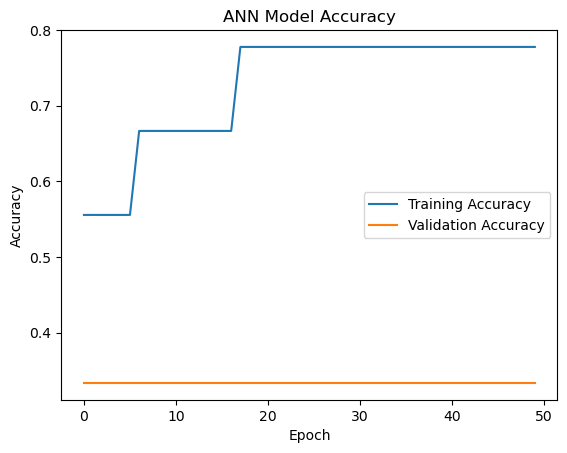

In [58]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("ANN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

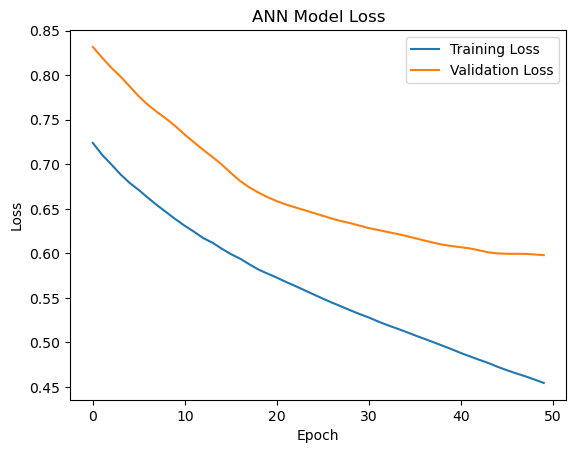

In [59]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("ANN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training Loss", "Validation Loss"])

plt.show()

In [60]:
y_pred_probability = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


In [61]:
y_pred = (y_pred_probability >= 0.5).astype(int)

In [62]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2 0]
 [1 0]]


In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


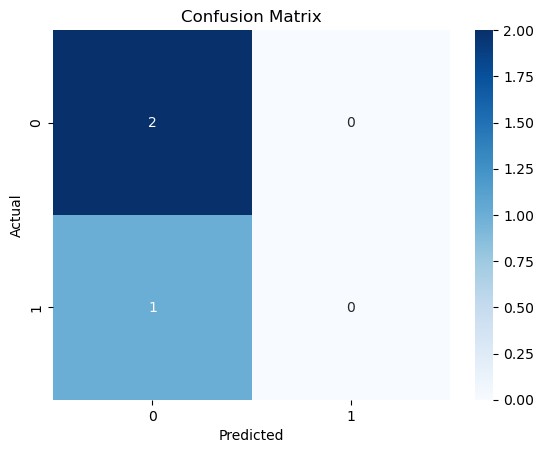

In [64]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [67]:
new_customer = x.iloc[[0]]

new_customer_scaled = scaler.transform(new_customer)

prediction = model.predict(new_customer_scaled)

if prediction[0][0] >= 0.5:
    print("Customer is likely to Churn")
else:
    print("Customer is likely to Stay")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Customer is likely to Churn
